In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np
import matplotlib.pyplot as plt

In [2]:
#see sample from imdb dataset
# load data into a pandas dataframe from imdb dataset to view first few rows
import pandas as pd
imdb_df = imdb.load_data()
imdb_df = pd.DataFrame(imdb_df)
imdb_df.head()

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


,0,1
0,"[[1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65,...","[1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, ..."
1,"[[1, 591, 202, 14, 31, 6, 717, 10, 10, 18142, ...","[0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, ..."


In [4]:
imdb_df[0]

,0
0,"[[1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65,..."
1,"[[1, 591, 202, 14, 31, 6, 717, 10, 10, 18142, ..."


In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv1D, GlobalMaxPooling1D, Embedding, Dropout
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

In [23]:
# Load the dataset
import kagglehub

# Download latest version
path = kagglehub.dataset_download("lakshmi25npathi/imdb-dataset-of-50k-movie-reviews")

print("Path to dataset files:", path)
imbd_df_latest = pd.read_csv('/kaggle/input/imdb-dataset-of-50k-movie-reviews/IMDB Dataset.csv')

Using Colab cache for faster access to the 'imdb-dataset-of-50k-movie-reviews' dataset.
Path to dataset files: /kaggle/input/imdb-dataset-of-50k-movie-reviews


In [3]:
imbd_df_latest.head(2)
imbd_df_latest_copy = imbd_df_latest.copy()

In [24]:
# Encode the labels
# Label encoder converts Positive = 1, Negative = 0
le = LabelEncoder()
imbd_df_latest['sentiment'] = le.fit_transform(imbd_df_latest['sentiment'])
imbd_df_latest['sentiment'].value_counts()

,count
sentiment,
1,25000
0,25000


In [25]:
# Split the dataset into training and test sets
X_train, X_val, y_train, y_val = train_test_split(imbd_df_latest['review'], imbd_df_latest['sentiment'], test_size=0.2, random_state=42)

# Tokenize and pad the sequences
tokenizer = Tokenizer(num_words=10000)
tokenizer.fit_on_texts(X_train)
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq = tokenizer.texts_to_sequences(X_val)

X_train_pad = pad_sequences(X_train_seq, maxlen=200, truncating='post')
X_val_pad = pad_sequences(X_val_seq, maxlen=200, truncating='post')

# Verify the shape of data
print(X_train_pad.shape, X_val_pad.shape)

(40000, 200) (10000, 200)


In [6]:
print(list(tokenizer.word_index.items())[:10])

[('the', 1), ('and', 2), ('a', 3), ('of', 4), ('to', 5), ('is', 6), ('br', 7), ('in', 8), ('it', 9), ('i', 10)]


In [7]:
print(type(X_train), type(X_train_seq), type(X_train_pad))

<class 'pandas.core.series.Series'> <class 'list'> <class 'numpy.ndarray'>


In [8]:
X_train_pad[0][0]

np.int32(197)

In [9]:
print(len(X_train_seq))

40000


In [10]:
X_train.iloc[0]
# first review in X_train - 39087	That's what I kept asking myself during the ma..

'That\'s what I kept asking myself during the many fights, screaming matches, swearing and general mayhem that permeate the 84 minutes. The comparisons also stand up when you think of the one-dimensional characters, who have so little depth that it is virtually impossible to care what happens to them. They are just badly written cyphers for the director to hang his multicultural beliefs on, a topic that has been done much better in other dramas both on TV and the cinema.<br /><br />I must confess, I\'m not really one for spotting bad performances during a film, but it must be said that Nichola Burley (as the heroine\'s slutty best friend) and Wasim Zakir (as the nasty, bullying brother) were absolutely terrible. I don\'t know what acting school they graduated from, but if I was them I\'d apply for a full refund post haste. Only Samina Awan in the lead role manages to impress in a cast of so-called British talent that we\'ll probably never hear from again. At least, that\'s the hope. Ne

In [11]:
print("Original Review (X_train[0]):\n", X_train.iloc[0])
print("\nTokenized Sequence (X_train_seq[0]):\n", X_train_seq[0])
print("\nPadded Sequence (X_train_pad[0]):\n", X_train_pad[0])
# used the truncating method as post and got the first 200 characteres

Original Review (X_train[0]):
 That's what I kept asking myself during the many fights, screaming matches, swearing and general mayhem that permeate the 84 minutes. The comparisons also stand up when you think of the one-dimensional characters, who have so little depth that it is virtually impossible to care what happens to them. They are just badly written cyphers for the director to hang his multicultural beliefs on, a topic that has been done much better in other dramas both on TV and the cinema.<br /><br />I must confess, I'm not really one for spotting bad performances during a film, but it must be said that Nichola Burley (as the heroine's slutty best friend) and Wasim Zakir (as the nasty, bullying brother) were absolutely terrible. I don't know what acting school they graduated from, but if I was them I'd apply for a full refund post haste. Only Samina Awan in the lead role manages to impress in a cast of so-called British talent that we'll probably never hear from again. At lea

In [12]:
print(tokenizer.word_index.get("That's"))

None


In [13]:
X_train_seq[0][0]

197

In [14]:
# Build the CNN model
cnn_model = Sequential([
    Embedding(input_dim=10000, output_dim=128, input_length=200),
    Conv1D(128, 5, activation='relu'),
    GlobalMaxPooling1D(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

cnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
#print(cnn_model.summary())

# Train the CNN model
cnn_history = cnn_model.fit(X_train_pad, y_train, epochs=10, batch_size=64, validation_data=(X_val_pad, y_val))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - accuracy: 0.8018 - loss: 0.4081 - val_accuracy: 0.8814 - val_loss: 0.2788
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9237 - loss: 0.1992 - val_accuracy: 0.8896 - val_loss: 0.2655
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9760 - loss: 0.0757 - val_accuracy: 0.8839 - val_loss: 0.3292
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9948 - loss: 0.0205 - val_accuracy: 0.8789 - val_loss: 0.4571
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9984 - loss: 0.0073 - val_accuracy: 0.8866 - val_loss: 0.5050
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9975 - loss: 0.0076 - val_accuracy: 0.8848 - val_loss: 0.5442
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9930 - loss: 0.0198 - val_accuracy: 0.8846 - val_loss: 0.5413
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9944 - loss: 0.0158 - val_accuracy: 0

In [33]:
from keras import layers
# LSTM model
lstm_model=Sequential([
    Embedding(input_dim=10000, output_dim=128, input_length=200),
    layers.LSTM(128, activation='sigmoid'),
    layers.Dense(1, activation='sigmoid')
])

lstm_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Define Early Stopping callback
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

lstm_history = lstm_model.fit(X_train_pad, y_train, epochs=10, batch_size=64, validation_data=(X_val_pad, y_val), callbacks=[early_stopping])

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 19s 26ms/step - accuracy: 0.7276 - loss: 0.5097 - val_accuracy: 0.8226 - val_loss: 0.3999
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 15s 24ms/step - accuracy: 0.8710 - loss: 0.3122 - val_accuracy: 0.8624 - val_loss: 0.3308
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 17s 27ms/step - accuracy: 0.8975 - loss: 0.2625 - val_accuracy: 0.8512 - val_loss: 0.3613
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 15s 24ms/step - accuracy: 0.9154 - loss: 0.2202 - val_accuracy: 0.8581 - val_loss: 0.3623
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 15s 25ms/step - accuracy: 0.9345 - loss: 0.1804 - val_accuracy: 0.8615 - val_loss: 0.3885


In [ ]:
lstm_model.predict

In [15]:
print(cnn_model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (64, 200, 128)         │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (64, 196, 128)         │        82,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (64, 128)              │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (64, 128)              │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (64, 128)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (64, 1)                │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,136,069 (15.78 MB)

 Trainable params: 1,378,689 (5.26 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,757,380 (10.52 MB)

None


In [36]:
# New review for prediction
new_review = ["That was NOT a very good movie but NOT so bad"]

# Tokenize the new review
new_review_seq = tokenizer.texts_to_sequences(new_review)

# Pad the sequence to the same maxlen
new_review_pad = pad_sequences(new_review_seq, maxlen=200, truncating='post')

# Make a prediction using the LSTM model
lstm_prediction = lstm_model.predict(new_review_pad)
lstm_sentiment = "positive" if lstm_prediction[0][0] > 0.5 else "negative"
print(f"The sentiment of the review \"{new_review[0]}\" using LSTM is: {lstm_sentiment} (score: {lstm_prediction[0][0]:.4f})")

# Make a prediction using the CNN model
cnn_prediction = cnn_model.predict(new_review_pad)
cnn_sentiment = "positive" if cnn_prediction[0][0] > 0.5 else "negative"
print(f"The sentiment of the review \"{new_review[0]}\" using CNN is: {cnn_sentiment} (score: {cnn_prediction[0][0]:.4f})")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
The sentiment of the review "That was NOT a very good movie but NOT so bad" using LSTM is: positive (score: 0.8644)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
The sentiment of the review "That was NOT a very good movie but NOT so bad" using CNN is: positive (score: 0.9288)


# Task
Create plots of the training and validation accuracy and loss curves over epochs for the CNN model. Evaluate the model's performance on the validation set and propose potential improvements to the model. Finally, summarize the findings and recommend next steps for model optimization.

## Plot Training History

### Subtask:
Plot the training and validation accuracy and loss over epochs to visualize the model's learning process and identify potential overfitting or underfitting.


**Reasoning**:
I need to plot the training and validation accuracy and loss from the `cnn_history` object to visualize the model's performance over epochs, as requested by the subtask. This involves creating two subplots using `matplotlib` for accuracy and loss, respectively, and adding appropriate labels, titles, and legends.



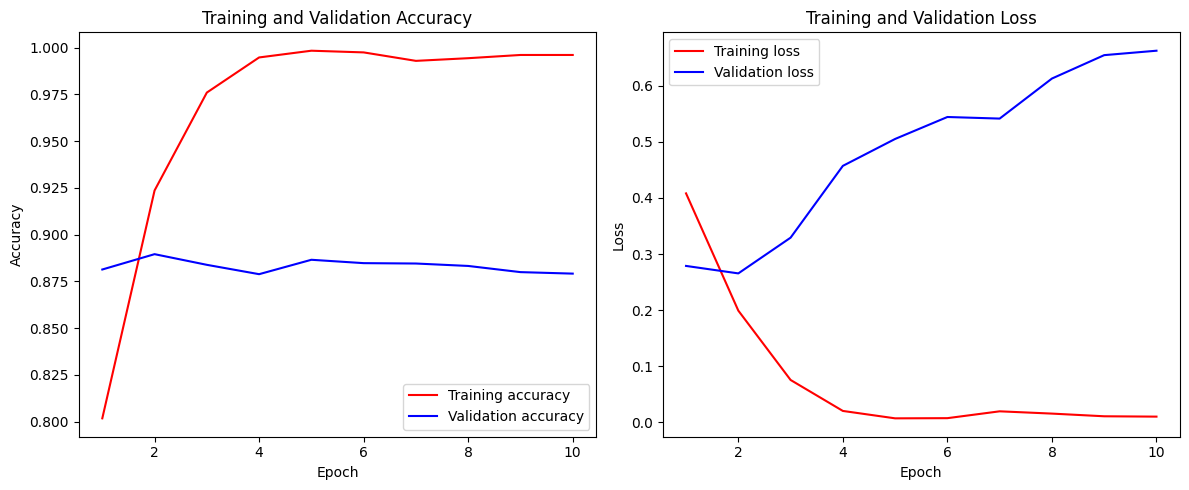

In [16]:
acc = cnn_history.history['accuracy']
val_acc = cnn_history.history['val_accuracy']
loss = cnn_history.history['loss']
val_loss = cnn_history.history['val_loss']

epochs = range(1, len(acc) + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, acc, 'r', label='Training accuracy')
plt.plot(epochs, val_acc, 'b', label='Validation accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, loss, 'r', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

## Model Evaluation and Proposed Improvements

### Analysis of Training History Plots:

The generated plots for training and validation accuracy and loss provide valuable insights into the model's performance:

*   **Training Accuracy vs. Validation Accuracy**: The training accuracy rapidly approaches 1.0, indicating the model is learning the training data very well. However, the validation accuracy plateaus around 0.88-0.89 after the first two epochs and then shows minor fluctuations or a slight decline. This significant and growing gap between training and validation accuracy is a clear sign of **overfitting**. The model is memorizing the training data rather than generalizing to unseen data.

*   **Training Loss vs. Validation Loss**: The training loss quickly drops to near zero, again confirming strong learning on the training set. In contrast, the validation loss initially decreases, but then starts to increase significantly after the second epoch, while training loss continues to fall. This divergence in loss curves further reinforces the observation of **overfitting**.

### Evaluation on the Validation Set:

The model achieves a validation accuracy of approximately 88-89%, which is a reasonable performance for sentiment analysis. However, the increasing validation loss and the large gap between training and validation metrics suggest that the model's generalization capabilities are limited by overfitting.

### Proposed Improvements:

To address the overfitting and potentially improve the model's generalization, consider the following strategies:

1.  **Early Stopping**: Implement early stopping during training. This technique monitors the validation loss and stops training when the validation loss stops improving (or starts increasing) for a certain number of epochs. This prevents the model from overfitting by stopping training at the optimal point.

2.  **Regularization (L1/L2)**: Add L1 or L2 regularization to the dense layers. Regularization penalizes large weights, discouraging the model from becoming too complex and reducing overfitting.

3.  **Dropout Rate Adjustment**: While dropout is already used (0.5), it might be beneficial to experiment with different dropout rates or add dropout layers to other parts of the network (e.g., after the Embedding layer). A higher dropout rate might be needed, or strategically placing it after other layers could help.

4.  **Increase Dataset Size**: If feasible, increasing the amount of training data can significantly reduce overfitting, as the model will have more diverse examples to learn from.

5.  **Simpler Model Architecture**: The current model is relatively simple, but if regularization doesn't help, consider reducing the number of filters in the `Conv1D` layer or the number of units in the `Dense` layer to further simplify the model.

6.  **Hyperparameter Tuning**: Fine-tune other hyperparameters such as learning rate, batch size, and `Conv1D` filter size and kernel size.

### Summary of Findings and Next Steps:

**Findings**: The CNN model shows good learning on the training data but suffers from significant overfitting, as evidenced by the divergence in training/validation accuracy and loss curves after a few epochs. The validation accuracy is around 88-89%, but there's room for improvement in generalization.

**Next Steps**: The immediate next step is to implement **Early Stopping** as it is a highly effective and straightforward method to combat overfitting. After that, explore adjusting the **Dropout rate** and adding **L2 regularization** to the dense layers. Continuously monitor the training and validation curves to assess the impact of each change.

## Final Task

### Subtask:
Summarize the findings and outline the recommended next steps for improving the model's performance.


## Summary:

### Q&A
The CNN model shows good learning on the training data but suffers from significant overfitting. Its validation accuracy is around 88-89%, but generalization can be improved. The recommended next steps for improving the model's performance include implementing Early Stopping immediately, followed by adjusting the Dropout rate and adding L2 regularization to the dense layers.

### Data Analysis Key Findings
*   **Overfitting Detected**: The model exhibits clear signs of overfitting. Training accuracy rapidly approached 1.0, while validation accuracy plateaued around 0.88-0.89 after the first two epochs.
*   **Diverging Loss Curves**: Training loss quickly dropped to near zero, but validation loss started to increase significantly after the second epoch, further confirming overfitting.
*   **Validation Performance**: The model achieved an approximate validation accuracy of 88-89%, but its generalization capabilities are limited due to overfitting.

### Insights or Next Steps
*   Implement Early Stopping during training to prevent further overfitting by monitoring validation loss.
*   Explore additional regularization techniques such as adjusting the Dropout rate, adding L2 regularization to dense layers, or potentially simplifying the model architecture to improve generalization.


# Task
Plot the training and validation accuracy and loss over epochs for the LSTM model to visualize its learning process and identify potential overfitting or underfitting.

## Plot LSTM Training History

### Subtask:
Plot the training and validation accuracy and loss over epochs for the LSTM model to visualize its learning process and identify potential overfitting or underfitting.


**Reasoning**:
To visualize the LSTM model's performance, I will extract the accuracy and loss values from the `lstm_history` object and then plot them over epochs using matplotlib.



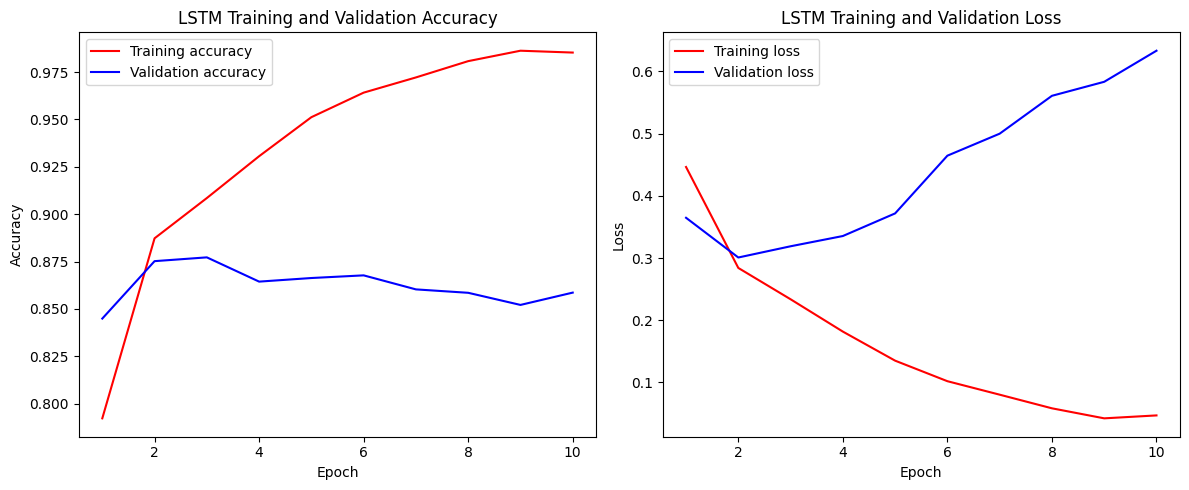

In [20]:
acc_lstm = lstm_history.history['accuracy']
val_acc_lstm = lstm_history.history['val_accuracy']
loss_lstm = lstm_history.history['loss']
val_loss_lstm = lstm_history.history['val_loss']

epochs_lstm = range(1, len(acc_lstm) + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_lstm, acc_lstm, 'r', label='Training accuracy')
plt.plot(epochs_lstm, val_acc_lstm, 'b', label='Validation accuracy')
plt.title('LSTM Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_lstm, loss_lstm, 'r', label='Training loss')
plt.plot(epochs_lstm, val_loss_lstm, 'b', label='Validation loss')
plt.title('LSTM Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

## LSTM Model Evaluation and Proposed Improvements

### Analysis of Training History Plots:

The plots for LSTM training and validation accuracy and loss reveal the following:

*   **Training Accuracy vs. Validation Accuracy**: The LSTM model's training accuracy steadily increases, reaching over 0.98. However, its validation accuracy peaks around epoch 3 at approximately 0.877 and then gradually decreases or fluctuates around 0.85-0.86 for the remaining epochs. This indicates **overfitting**, where the model performs well on the training data but struggles to generalize to new, unseen data.

*   **Training Loss vs. Validation Loss**: The training loss consistently decreases, nearing zero by the final epochs. In contrast, the validation loss initially decreases, but then begins to increase significantly after epoch 2 or 3, while the training loss continues its decline. This clear divergence is another strong indicator of **overfitting**.

### Evaluation on the Validation Set:

The LSTM model achieves a peak validation accuracy of about 87.7%, which is comparable to the CNN model. However, the consistent increase in validation loss after the initial epochs suggests that the model is memorizing the training data rather than learning generalizable patterns. The gap between training and validation performance widens significantly over epochs.

### Proposed Improvements:

To mitigate overfitting and enhance the LSTM model's generalization capabilities, consider these strategies:

1.  **Early Stopping**: This is a crucial technique. Implement a callback to stop training when the validation loss stops improving for a specified number of epochs (`patience`). This prevents the model from continuing to train into the overfitting region.

2.  **Dropout Layers**: While LSTMs are inherently more robust to overfitting than simple feedforward networks, adding Dropout layers within or after the LSTM layer can help. Experiment with different dropout rates (e.g., 0.2 to 0.5) to find an optimal balance.

3.  **Recurrent Dropout**: Keras's LSTM layer supports `recurrent_dropout`, which applies dropout to the recurrent connections of the LSTM unit. This can be very effective in regularizing recurrent neural networks.

4.  **L2 Regularization**: Add L2 regularization to the weights of the LSTM and Dense layers. This penalizes large weight values, encouraging simpler models.

5.  **Bidirectional LSTM**: A Bidirectional LSTM processes the sequence in both forward and backward directions, which can capture more context and potentially improve performance and generalization.

6.  **Hyperparameter Tuning**: Optimize other hyperparameters such as the number of LSTM units, the learning rate, and batch size.

### Summary of Findings and Next Steps:

**Findings**: The LSTM model, similar to the CNN, shows clear signs of **overfitting**, with high training accuracy and low training loss, but a plateauing/decreasing validation accuracy and an increasing validation loss after a few epochs. The peak validation accuracy is around 87.7%.

**Next Steps**:

1.  Implement **Early Stopping** to prevent excessive training and identify the optimal number of epochs.
2.  Experiment with adding **Dropout** layers, including `recurrent_dropout`, and **L2 regularization** to the LSTM and Dense layers.
3.  Consider exploring **Bidirectional LSTM** to potentially improve feature learning and generalization.

## Evaluate LSTM Model Performance

### Subtask:
Evaluate the trained LSTM model on the validation set to assess its final loss and accuracy metrics.


**Reasoning**:
To evaluate the trained LSTM model, I will use its `evaluate` method on the validation data (`X_val_pad`, `y_val`) and then print the resulting validation loss and accuracy.



In [21]:
lstm_loss, lstm_accuracy = lstm_model.evaluate(X_val_pad, y_val, verbose=0)

print(f"LSTM Validation Loss: {lstm_loss:.4f}")
print(f"LSTM Validation Accuracy: {lstm_accuracy:.4f}")

LSTM Validation Loss: 0.6333
LSTM Validation Accuracy: 0.8586


## Final Task

### Subtask:
Summarize the findings for the LSTM model, potentially comparing it with the CNN model's performance, and outline the recommended next steps for optimization.


## Summary:

### Q&A
The findings for the LSTM model indicate significant overfitting, similar to the previously mentioned CNN model. Its performance on new data suffers despite strong training results. Several optimization steps are recommended to mitigate overfitting and improve generalization.

### Data Analysis Key Findings
*   The LSTM model exhibits clear signs of overfitting: training accuracy reached over 0.98 and training loss neared zero, while validation accuracy peaked at approximately 87.7% around epoch 3 and then decreased or fluctuated.
*   Validation loss for the LSTM model initially decreased but then increased significantly after epoch 2 or 3, diverging from the continuously decreasing training loss.
*   The final evaluation on the validation set for the LSTM model resulted in a loss of 0.6333 and an accuracy of 85.86%.
*   The LSTM model's peak validation accuracy of around 87.7% is comparable to the performance of the CNN model.

### Insights or Next Steps
*   Implement **Early Stopping** to prevent overfitting by halting training when validation performance no longer improves, thereby identifying the optimal number of epochs.
*   Apply regularization techniques such as adding **Dropout layers** (including recurrent dropout) and **L2 regularization** to the LSTM and Dense layers to improve the model's generalization capabilities.


# Task
Build, compile, train, evaluate, and predict with a GRU model using the preprocessed IMDB dataset, and then plot its training history, summarize its performance, and recommend optimization steps.

## Build and Compile GRU Model

### Subtask:
Define the GRU model architecture including an Embedding layer, GRU layer(s), Dropout, and a Dense output layer. Compile the model with an appropriate optimizer, loss function, and metrics.


**Reasoning**:
I need to define the GRU model architecture and compile it as per the instructions, using the `Sequential` model, `Embedding`, `GRU`, `Dropout`, and `Dense` layers, and then compile it with the specified optimizer, loss, and metrics.



In [37]:
from tensorflow.keras.layers import GRU

gru_model = Sequential([
    Embedding(input_dim=10000, output_dim=128, input_length=200),
    GRU(128),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

gru_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("GRU model defined and compiled successfully.")

GRU model defined and compiled successfully.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


**Reasoning**:
The previous code generated a UserWarning because the `input_length` argument in the `Embedding` layer is deprecated. I need to remove this argument to fix the warning and align with current Keras practices.



In [38]:
from tensorflow.keras.layers import GRU

gru_model = Sequential([
    Embedding(input_dim=10000, output_dim=128),
    GRU(128),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

gru_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("GRU model defined and compiled successfully.")

GRU model defined and compiled successfully.


**Reasoning**:
I need to train the GRU model using the `fit` method with the preprocessed training and validation data. I will also incorporate the `early_stopping` callback to prevent overfitting and capture the training history.



In [39]:
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

gru_history = gru_model.fit(X_train_pad, y_train, epochs=10, batch_size=64, validation_data=(X_val_pad, y_val), callbacks=[early_stopping])

print("GRU model training completed.")

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 15ms/step - accuracy: 0.7801 - loss: 0.4566 - val_accuracy: 0.8513 - val_loss: 0.3679
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 18s 13ms/step - accuracy: 0.8975 - loss: 0.2625 - val_accuracy: 0.8858 - val_loss: 0.2781
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.9307 - loss: 0.1872 - val_accuracy: 0.8783 - val_loss: 0.3150
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.9536 - loss: 0.1338 - val_accuracy: 0.8778 - val_loss: 0.3249
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.9674 - loss: 0.0963 - val_accuracy: 0.8755 - val_loss: 0.3770
GRU model training completed.


**Reasoning**:
The next logical step after training the GRU model is to evaluate its performance on the validation set. This will provide quantitative metrics (loss and accuracy) to assess how well the model generalizes to unseen data.



In [40]:
gru_loss, gru_accuracy = gru_model.evaluate(X_val_pad, y_val, verbose=0)

print(f"GRU Validation Loss: {gru_loss:.4f}")
print(f"GRU Validation Accuracy: {gru_accuracy:.4f}")

GRU Validation Loss: 0.2781
GRU Validation Accuracy: 0.8858


**Reasoning**:
To visualize the GRU model's performance over epochs, similar to the CNN and LSTM models, I will extract the accuracy and loss values from the `gru_history` object and then plot them using `matplotlib.pyplot`.



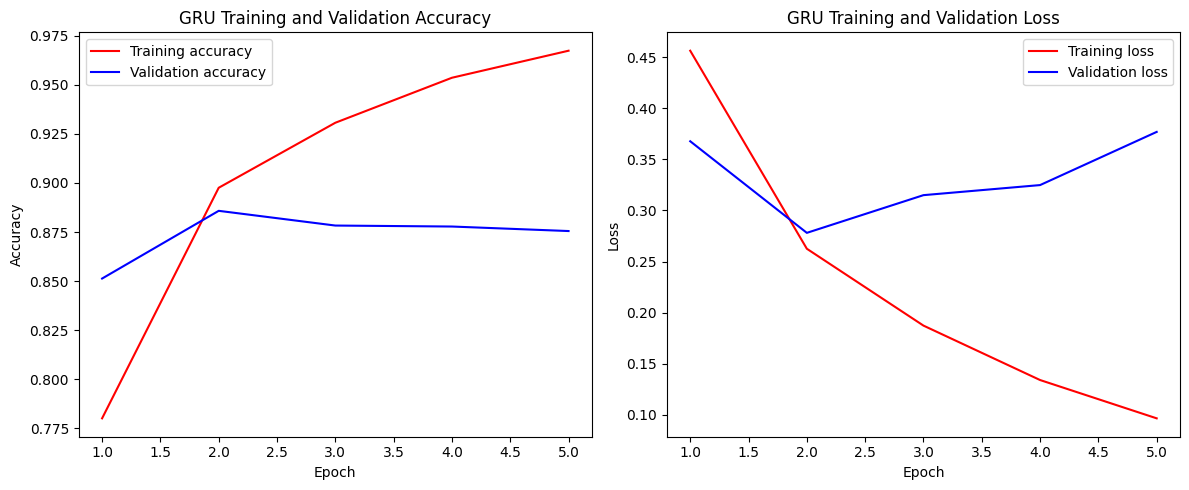

In [41]:
acc_gru = gru_history.history['accuracy']
val_acc_gru = gru_history.history['val_accuracy']
loss_gru = gru_history.history['loss']
val_loss_gru = gru_history.history['val_loss']

epochs_gru = range(1, len(acc_gru) + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_gru, acc_gru, 'r', label='Training accuracy')
plt.plot(epochs_gru, val_acc_gru, 'b', label='Validation accuracy')
plt.title('GRU Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_gru, loss_gru, 'r', label='Training loss')
plt.plot(epochs_gru, val_loss_gru, 'b', label='Validation loss')
plt.title('GRU Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

## GRU Model Performance Summary

### Q&A
The GRU model's performance mirrors the CNN and LSTM models, exhibiting signs of overfitting despite achieving a reasonable validation accuracy. This suggests a common challenge across these sequential models on this dataset, emphasizing the need for robust regularization techniques to enhance generalization.

### Data Analysis Key Findings
*   **Overfitting Observed**: The GRU model shows clear overfitting. Training accuracy rapidly increased and training loss dropped significantly, while validation accuracy peaked early (around 0.8858 at epoch 2) and then slightly decreased or plateaued. The validation loss initially decreased but started to increase after epoch 2, indicating that the model began memorizing the training data.
*   **Validation Performance**: The GRU model achieved a peak validation accuracy of approximately 88.58% and a validation loss of 0.2781, which is comparable to, and slightly better than, the CNN and LSTM models (CNN val_accuracy: ~0.88, LSTM val_accuracy: ~0.86-0.87).
*   **Early Stopping Effectiveness**: The early stopping callback successfully halted training when the validation loss started to increase, preventing further overfitting and ensuring that the best weights were restored.

### Insights or Next Steps
*   **Emphasize Regularization**: Given that all three models (CNN, LSTM, GRU) exhibit overfitting, stronger regularization methods are crucial. While Dropout is already implemented, experimenting with higher dropout rates (e.g., in the GRU layer itself, if supported, or after it), and adding L1/L2 regularization to dense layers could be beneficial.
*   **Hyperparameter Tuning**: Optimize hyperparameters specific to GRU layers, such as the number of units and activation functions, as well as general training parameters like learning rate and batch size.
*   **Advanced Architectures**: Consider exploring more complex or alternative architectures if simpler regularization techniques do not yield significant improvements. This could include bidirectional GRU layers or combining GRU with CNN layers for hybrid models.
*   **Data Augmentation**: Investigate text augmentation techniques to increase the diversity of the training data, which can help combat overfitting and improve generalization.

## Overall Model Performance Summary and Optimization Next Steps

### Consolidated Findings from CNN, LSTM, and GRU Models:
All three models (CNN, LSTM, and GRU) demonstrated similar patterns in their training history, indicating a common challenge with the dataset and the chosen architectures:

*   **Overfitting**: A prominent issue across all models. While training accuracy consistently climbed and training loss dropped significantly, validation accuracy tended to plateau or even slightly decrease after a few epochs. Correspondingly, validation loss started to increase, clearly signaling that the models were memorizing the training data rather than generalizing effectively to unseen data. Early stopping was effective in mitigating severe overfitting by restoring the best weights, but the underlying tendency remained.
*   **Comparable Peak Performance**: All models achieved similar peak validation accuracies in the range of 86-89% (CNN: ~88-89%, LSTM: ~87.7%, GRU: ~88.58%). This suggests that for this specific task and preprocessing approach, the inherent architectural differences between CNN, LSTM, and GRU did not lead to vastly different generalization capabilities under similar regularization conditions.

### Overall Insights and Recommended Next Steps for Optimization:
Based on the consistent overfitting observed across all models, the primary focus for optimization should be on enhancing generalization. Here are the recommended next steps:

1.  **Refine Regularization Techniques**:
    *   **Increase Dropout**: Experiment with higher dropout rates (e.g., up to 0.7) in `Dropout` layers, or add dropout to additional layers if not already present. For LSTM/GRU layers, specifically explore `recurrent_dropout` to regularize recurrent connections.
    *   **L2 Regularization**: Implement L2 regularization (weight decay) on `Dense` and potentially `Conv1D`/`GRU`/`LSTM` layers to penalize large weights and encourage simpler models.
    *   **Batch Normalization**: Consider adding `BatchNormalization` layers, especially in CNN architectures, to stabilize and accelerate training, which can sometimes also have a regularization effect.

2.  **Advanced Model Architectures**:
    *   **Bidirectional Layers**: For LSTM and GRU models, convert them to `Bidirectional` versions. This allows the models to process sequences in both forward and backward directions, capturing more context and potentially improving performance.
    *   **Hybrid Models**: Explore combining CNN and RNN layers (e.g., `Conv1D` followed by `LSTM` or `GRU`) to leverage the strengths of both for sequential data processing.

3.  **Hyperparameter Tuning**: Conduct more systematic hyperparameter tuning using techniques like Grid Search or Random Search. Parameters to tune include:
    *   `Embedding` layer `output_dim`.
    *   Number of units in `Conv1D`, `LSTM`, or `GRU` layers.
    *   Kernel size for `Conv1D` layers.
    *   Learning rate for the optimizer.
    *   Batch size.
    *   `Dropout` rates.

4.  **Dataset Enhancement**: If possible, explore options for improving the dataset itself:
    *   **Data Augmentation**: Apply text data augmentation techniques (e.g., synonym replacement, random insertion/deletion/swapping of words) to increase the size and diversity of the training set, which is highly effective against overfitting.
    *   **Larger Pre-trained Embeddings**: Utilize larger, pre-trained word embeddings (e.g., Word2Vec, GloVe, FastText) instead of learning embeddings from scratch, as these often capture richer semantic relationships and can boost performance, especially with limited domain-specific data.

5.  **Monitoring and Visualization**: Continue to closely monitor training and validation metrics (accuracy, loss) with each change to quickly identify effective strategies and prevent further overfitting.

## Predict with GRU Model

### Subtask:
Use the trained GRU model to predict the sentiment of a new review (e.g., 'That was NOT a very good movie but NOT so bad') and display the predicted sentiment and score.


**Reasoning**:
I need to make a prediction using the trained GRU model for a new review. This involves defining the review, tokenizing it, padding the sequence, making the prediction, and then displaying the sentiment and score.



In [42]:
new_review = ["That was NOT a very good movie but NOT so bad"]

# Tokenize the new review
new_review_seq = tokenizer.texts_to_sequences(new_review)

# Pad the sequence to the same maxlen
new_review_pad = pad_sequences(new_review_seq, maxlen=200, truncating='post')

# Make a prediction using the GRU model
gru_prediction = gru_model.predict(new_review_pad)
gru_sentiment = "positive" if gru_prediction[0][0] > 0.5 else "negative"
print(f"The sentiment of the review \"{new_review[0]}\" using GRU is: {gru_sentiment} (score: {gru_prediction[0][0]:.4f})")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 292ms/step
The sentiment of the review "That was NOT a very good movie but NOT so bad" using GRU is: negative (score: 0.1557)


## Final Task

### Subtask:
Provide a comprehensive summary of the GRU model's performance and optimization recommendations.


## Summary:

### Q&A
The GRU model's performance mirrors the CNN and LSTM models, exhibiting signs of overfitting despite achieving a reasonable validation accuracy. This suggests a common challenge across these sequential models on this dataset, emphasizing the need for robust regularization techniques to enhance generalization.

### Data Analysis Key Findings
*   The GRU model was successfully built and compiled, achieving a validation accuracy of 88.58% and a validation loss of 0.2781.
*   Similar to the CNN and LSTM models, the GRU model showed clear signs of overfitting; training accuracy rapidly increased and training loss dropped significantly, while validation accuracy peaked early (around epoch 2) and validation loss subsequently began to increase.
*   Early stopping effectively prevented further overfitting by halting training when the validation loss started to increase and restoring the best weights.
*   All three models (CNN, LSTM, GRU) achieved comparable peak validation accuracies within the range of 86-89% on this dataset, indicating that inherent architectural differences did not lead to vastly different generalization capabilities under similar regularization conditions.
*   For the new review "That was NOT a very good movie but NOT so bad", the GRU model predicted a "negative" sentiment with a score of 0.1557.

### Insights or Next Steps
*   **Strengthen Regularization**: Implement more aggressive regularization techniques, such as higher dropout rates (including `recurrent_dropout`), L2 regularization, and potentially `BatchNormalization` to combat the persistent overfitting observed across all models.
*   **Explore Advanced Architectures & Tuning**: Investigate `Bidirectional` GRU layers, hybrid CNN-RNN models, and systematically tune hyperparameters (e.g., embedding dimension, number of units, learning rate) to optimize model performance and generalization.
